# Entrenamiento de ResNet50 para clasificación binaria de tumores ováricos

Este notebook tiene como objetivo entrenar la arquitectura ResNet50 bajo el protocolo experimental definido para la clasificación automática de tumores ováricos benignos y malignos mediante imágenes ecográficas 2D.

Se emplea transferencia de aprendizaje utilizando pesos preentrenados y una función de pérdida ponderada para considerar el desbalance presente en el conjunto de datos.

## Configuración experimental

La configuración utilizada corresponde al baseline del benchmark de arquitecturas CNN.

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn as nn

PROJECT_DIR = Path("../..").resolve()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print(PROJECT_DIR)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification


## Importación de componentes desarrollados

In [2]:
from src.classification.transforms import (
    get_classification_transforms
)

from src.classification.dataset import (
    MMOTUClassificationDataset
)

from src.classification.dataloader import (
    create_dataloader
)

from src.classification.models import (
    create_resnet50_classifier
)

from src.classification.train import (
    train_model
)

from src.classification.utils import (
    compute_class_weights
)

## Configuración del dispositivo

Se utilizará aceleración mediante GPU CUDA cuando esté disponible.

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [4]:
DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "MMOTU_OTU_2D_experimental"
)


CSV_PATH = (
    PROJECT_DIR /
    "configs" /
    "splits" /
    "mmotu_experimental_split_standard.csv"
)

In [5]:
transform = get_classification_transforms()


train_dataset = MMOTUClassificationDataset(
    CSV_PATH,
    DATA_DIR,
    "train",
    transform
)


val_dataset = MMOTUClassificationDataset(
    CSV_PATH,
    DATA_DIR,
    "validation",
    transform
)


test_dataset = MMOTUClassificationDataset(
    CSV_PATH,
    DATA_DIR,
    "test",
    transform
)

In [6]:
train_loader = create_dataloader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = create_dataloader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [17]:
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))

Train: 25
Validation: 7
Test: 15


## Inicialización de la arquitectura ResNet50

Se utiliza la arquitectura ResNet50 mediante transferencia de aprendizaje.

In [8]:
model = create_resnet50_classifier(
    pretrained=True,
    num_classes=2,
    freeze_backbone=False
)

model = model.to(device)

In [9]:
print(model.fc)

Linear(in_features=2048, out_features=2, bias=True)


## Configuración de la función de pérdida

Debido al desbalance observado en el conjunto de entrenamiento, se emplea una función CrossEntropyLoss ponderada.

In [10]:
import pandas as pd


train_df = pd.read_csv(
    CSV_PATH
)


train_labels = (
    train_df[
        train_df["experimental_split"]=="train"
    ]["binary_label"]
    .values
)

In [11]:
class_weights = compute_class_weights(
    train_labels
)

print(class_weights)

tensor([0.5610, 4.5977])


In [12]:
class_weights = class_weights.to(device)

In [13]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

## Configuración del optimizador

Se utiliza AdamW como optimizador debido a su comportamiento estable en escenarios de transferencia de aprendizaje y ajuste fino de redes profundas.

Los hiperparámetros corresponden al protocolo experimental base definido para la comparación de arquitecturas.

In [14]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [15]:
MODEL_DIR = (
    PROJECT_DIR /
    "models" /
    "classification"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SAVE_PATH = (
    MODEL_DIR /
    "resnet50_baseline_best.pth"
)

print(SAVE_PATH)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/models/classification/resnet50_baseline_best.pth


In [19]:
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    save_path=SAVE_PATH
)

Epoch 1/30
Train Loss: 0.4186 | Train Acc: 0.9137
Val Loss: 0.8121 | Val Acc: 0.9000
Modelo guardado
Epoch 2/30
Train Loss: 0.1350 | Train Acc: 0.9762
Val Loss: 1.3666 | Val Acc: 0.8950
Epoch 3/30
Train Loss: 0.0395 | Train Acc: 0.9988
Val Loss: 1.7278 | Val Acc: 0.8900
Epoch 4/30
Train Loss: 0.0201 | Train Acc: 0.9950
Val Loss: 1.5036 | Val Acc: 0.9250
Epoch 5/30
Train Loss: 0.0100 | Train Acc: 0.9988
Val Loss: 1.7133 | Val Acc: 0.9000
Epoch 6/30
Train Loss: 0.0055 | Train Acc: 1.0000
Val Loss: 1.7631 | Val Acc: 0.9000
Epoch 7/30
Train Loss: 0.0054 | Train Acc: 0.9988
Val Loss: 1.4632 | Val Acc: 0.9100
Epoch 8/30
Train Loss: 0.0037 | Train Acc: 1.0000
Val Loss: 1.9460 | Val Acc: 0.8950
Epoch 9/30
Train Loss: 0.0020 | Train Acc: 1.0000
Val Loss: 1.7719 | Val Acc: 0.8950
Epoch 10/30
Train Loss: 0.0019 | Train Acc: 1.0000
Val Loss: 1.7143 | Val Acc: 0.9050
Epoch 11/30
Train Loss: 0.0017 | Train Acc: 1.0000
Val Loss: 1.7819 | Val Acc: 0.9100
Epoch 12/30
Train Loss: 0.0013 | Train Acc: 1.0

In [20]:
history.keys()

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])

In [21]:
history

{'train_loss': [0.4186267578601837,
  0.13495965003967286,
  0.03949593748897314,
  0.02008851112797856,
  0.01004676847718656,
  0.0054693610221147534,
  0.005430722972378134,
  0.0037176102260127663,
  0.0020403448678553105,
  0.0018980460800230503,
  0.0017360456043388694,
  0.0012925494404044003,
  0.0010319806449115277,
  0.0007517429802101106,
  0.0007143314846325666,
  0.000715835580485873,
  0.0006475101277465,
  0.000515003966866061,
  0.00042523490730673075,
  0.00044871899648569525,
  0.0002715033706044778,
  0.00031358250707853587,
  0.0003057844698196277,
  0.00025154260714771226,
  0.00039335290668532255,
  0.0002176676454837434,
  0.00023703441896941513,
  0.00025939718878362325,
  0.00023171113658463583,
  0.00018775271280901506],
 'train_acc': [0.91375,
  0.97625,
  0.99875,
  0.995,
  0.99875,
  1.0,
  0.99875,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0

## Curvas de aprendizaje

Se visualiza la evolución de las métricas durante el entrenamiento con el objetivo de analizar el comportamiento del modelo y detectar posibles tendencias de sobreajuste.

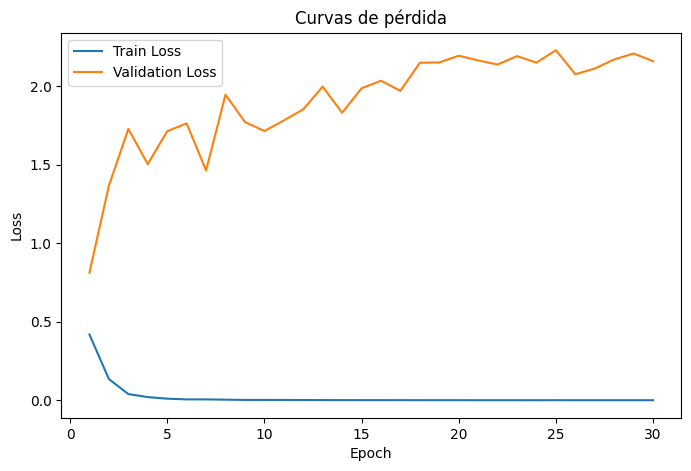

In [22]:
import matplotlib.pyplot as plt


epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida")
plt.legend()
plt.show()

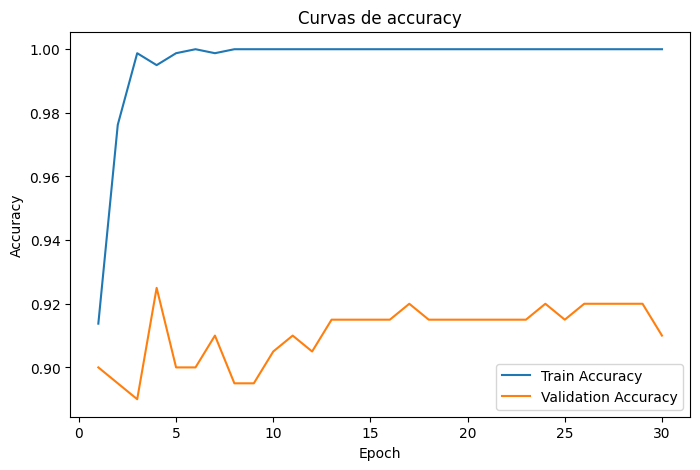

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de accuracy")
plt.legend()
plt.show()

## Almacenamiento de curvas de aprendizaje

Las curvas de aprendizaje permiten analizar la evolución del modelo durante el entrenamiento y observar posibles tendencias de sobreajuste.

In [24]:
# Guardar historial de entrenamiento en un archivo JSON
import json

RESULT_DIR = (
    PROJECT_DIR /
    "results" /
    "classification" /
    "resnet50_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


with open(
    RESULT_DIR / "history.json",
    "w"
) as f:

    json.dump(
        history,
        f,
        indent=4
    )

In [27]:
RESULT_DIR = (
    PROJECT_DIR /
    "results" /
    "classification" /
    "resnet50_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

### Guardar Imagenes

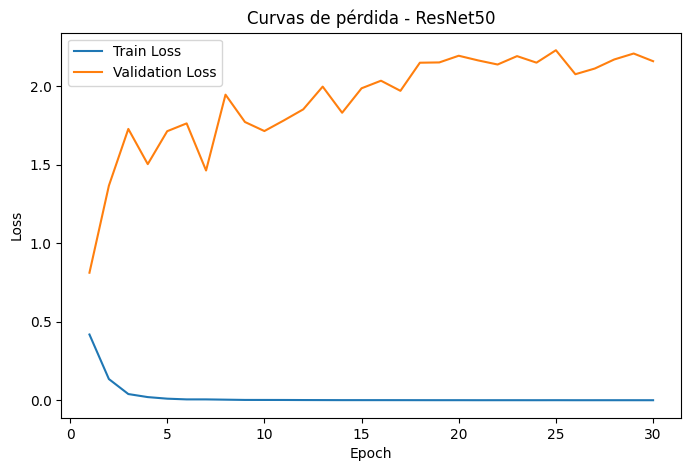

In [28]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida - ResNet50")

plt.legend()

plt.savefig(
    RESULT_DIR / "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

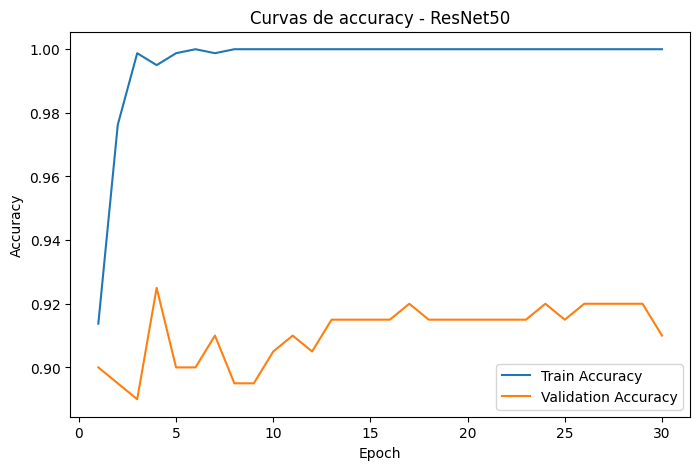

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de accuracy - ResNet50")

plt.legend()

plt.savefig(
    RESULT_DIR / "accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()